In [ ]:
!pip install -q polytope

import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cvx
import polytope as pc
from scipy.spatial import ConvexHull
from itertools import product
import time
import sys

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


# **H-Polytope**
**H-политоп** $\{x: Ax \le b \}$

## **Задача:** Постройте H-политопы для прямоугольника, ромба (квадрат повернутый на 45 градусов) и треугольника

(-2.0, 2.0)

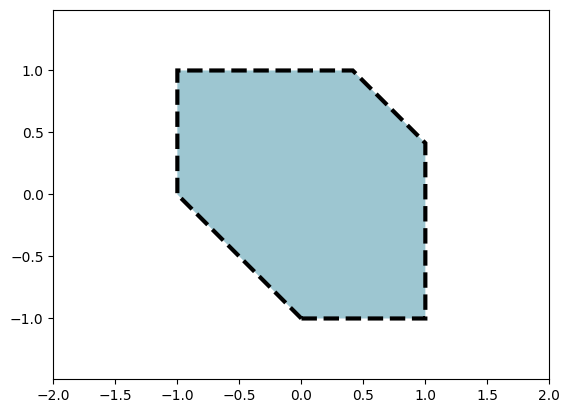

In [ ]:
p = pc.Polytope(A, b)
p.plot()
plt.axis('equal')
plt.xlim(-2, 2)
plt.ylim(-2, 2)

In [ ]:
pc.extreme(p)

array([[-0.     , -1.     ],
       [ 1.     , -1.     ],
       [ 1.     ,  0.41421],
       [ 0.41421,  1.     ],
       [-1.     ,  1.     ],
       [-1.     , -0.     ]])

## **Задача:** Измените знвчения матрицы $A$ и вектора $b$ так, чтобы они описывали одинаковые выпуклые множества.

In [ ]:
# Ваш код

## **Задача:** Поверните политопы (как пример на 45 градусов)


In [ ]:
# Ваш код

## **Задача:** Переместите политопы по оси x и оси y

In [ ]:
# Ваш код

## **Задача:** Постройте случайный H-политоп; выделите несколько точек внутри политопа и одну вне политопа; реализуйте проверку, находиться ли точка внутрии политоп при помощи **Numpy** и **Cvxpy**

(True, False)

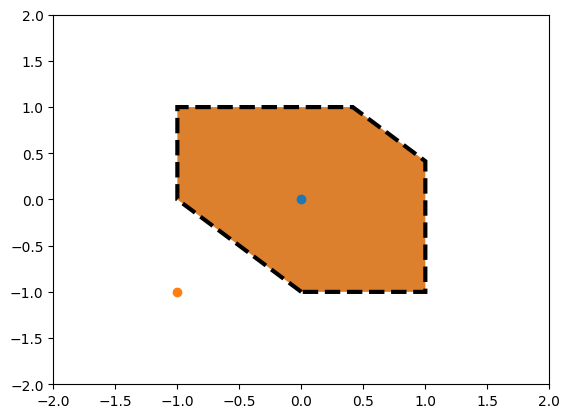

In [ ]:
# p = pc.Polytope(A, b)

p.plot()
plt.xlim(-2, 2)
plt.ylim(-2, 2)

x_in = np.array([0, 0])
x_out = np.array([-1,-1])
plt.scatter(*x_in)
plt.scatter(*x_out)

x_in in p, x_out in p

### **Numpy**

(np.float64(-2.2), np.float64(2.2), np.float64(-2.2), np.float64(2.2))

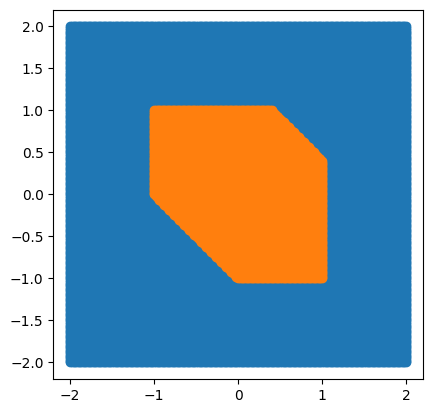

In [ ]:
x = np.linspace(-2, 2, 201)
y = np.linspace(-2, 2, 201)

X, Y = np.meshgrid(x, y)

X = X.reshape((-1, 1))
Y = Y.reshape((-1, 1))

# Множество точек в квадрате 4 на 4 с ценром в (0,0)
states = np.hstack((X, Y))

plt.scatter(*states.T)
plt.scatter(*valid.T)
plt.axis('scaled')

### **Cvxpy**

In [ ]:
A = np.array([[ 0.0    ,  1.0    ],
              [ 1.0    ,  0.0    ],
              [ 0.0    , -1.0    ],
              [-1.0    ,  0.0    ],
              [-0.70711, -0.70711],
              [ 0.70711,  0.70711],])

b = np.array([[1, 1, 1, 1, 0.70711, 1]]).T
x = cvx.Parameter((2,1))

objective = cvx.Minimize(0)
constraints = [A@x <= b]
problem = cvx.Problem(objective, constraints)

x.value = x_in.reshape((-1,1))
result = problem.solve(verbose=True)
optimal_in = problem.status == cvx.OPTIMAL


x.value = x_out.reshape((-1,1))
result = problem.solve(verbose=False)
optimal_out = problem.status == cvx.OPTIMAL

print(f'Status in: {optimal_in}')
print(f'Status out: {optimal_out}')

## **Задача:** Задайте окружность определенного радиуса, аппроксимируйте окружность H-политопом, оцените точность аппроксимации в зависимости от размера политопа

In [ ]:
# Ваш код

# **V-Polytope**
**V-политоп** $\{x = \sum^{N}_{i=1} x_i \alpha_i: \alpha_i \ge 0, \sum^{N}_{i=1} \alpha_i = 1 \}$

## **Задача:** Постройте V-политопы для прямоугольника, ромба (квадрат повернутый на 45 градусов) и треугольника

(-2.0, 2.0)

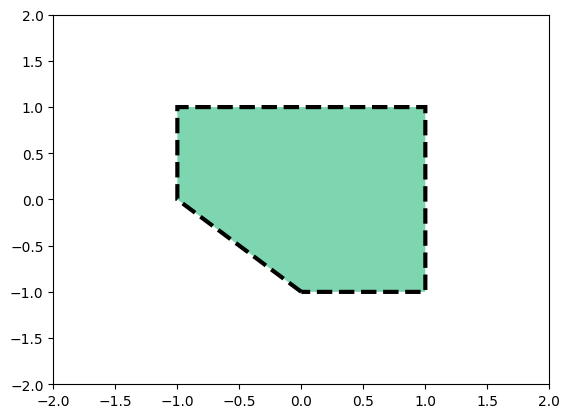

In [ ]:
v = pc.qhull(vertex)

v.plot()
plt.xlim(-2, 2)
plt.ylim(-2, 2)

## **Задача:** Переместите политопы по оси x и оси y

In [ ]:
# Ваш код

## **Задача:** Добавьте точки внутрь политопа и считайте их вершинами. Постройте политоп.

In [ ]:
# Ваш код

## **Задача:** Найдите матрицу $A$ и $b$ для V-политопа, при помощи метода пристального взгляда и **Polytope**

In [ ]:
# Ваш код

## **Задача:** Найдите вершины для H-политопа, при помощи метода пристального взгляда и **Polytope**

In [ ]:
# Ваш код

## **Задача:** Реализуйте проверку, находиться ли точка внутри политопа, при помощи **Cvxpy**

(array([[0.06195],
        [0.50097],
        [0.20668],
        [0.08471],
        [0.14569]]),
 np.float64(0.9999999999999999))

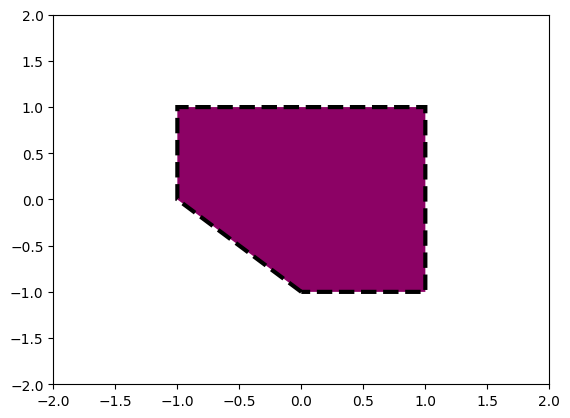

In [ ]:
# Ваш код
vertex = np.array([[ 1,-1],
                   [-1, 1],
                   [-1, 0],
                   [ 0,-1],
                   [ 1, 1]]).T

v = pc.qhull(vertex.T)

v.plot()
plt.xlim(-2, 2)
plt.ylim(-2, 2)

x_des = cvx.Parameter((2,1), name='x_des')
s = cvx.Variable((5,1))
objective = cvx.Minimize(0)
constraints = [vertex @ s == x_des,
               cvx.sum(s) == 1,
               s >= np.zeros_like(s)]
problem = cvx.Problem(objective, constraints)

x_des.value = np.array([[-0.5, 0.5]]).T
result = problem.solve()
s.value, np.sum(s.value)

## **Задача:** Задайте окружность определенного радиуса, аппроксимируйте окружность V-политопом, оцените точность аппроксимации в зависимости от размера политопа

In [ ]:
# Ваш код

## **Zonotope** (Z-polytope)
Z-политоп $\{x: x=G \beta + c, ||\beta||_\infty \le 1 \}$

## **Задача:** Реализуйте три зонотопа ($G, G_1, G_2, \beta, c$), два из которых состоят из частей матрицы (генератора) $G$

(array([[ 1. ,  0. ,  0.5],
        [ 0. ,  0.5, -1. ]]),
 array([[-1.    , -1.    , -1.    ],
        [-1.    , -1.    , -0.9798],
        [-1.    , -1.    , -0.9596],
        ...,
        [ 1.    ,  1.    ,  0.9596],
        [ 1.    ,  1.    ,  0.9798],
        [ 1.    ,  1.    ,  1.    ]]),
 array([[-1.5   , -1.4899, -1.4798, ...,  1.4798,  1.4899,  1.5   ],
        [ 0.5   ,  0.4798,  0.4596, ..., -0.4596, -0.4798, -0.5   ]]))

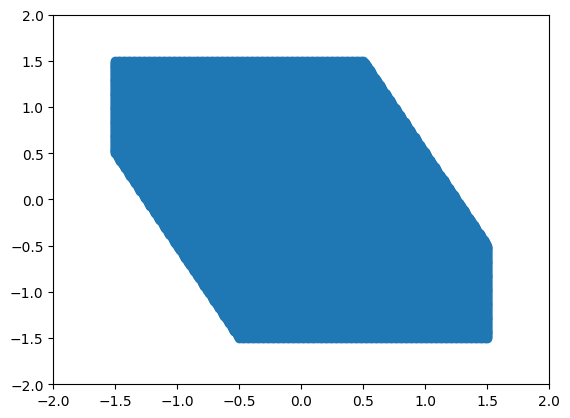

In [ ]:
signs = np.array(list(product(np.linspace(-1,1,100), repeat=3)))
G = np.array([[  1,   0],
              [  0, 0.5],
              [0.5,  -1]]).T
v = G@signs.T

plt.scatter(*v)
plt.xlim(-2, 2)
plt.ylim(-2, 2)
G, signs, v

In [ ]:
signs.shape

(1000000, 3)

# QP

**Задача:** Есть постановка проблемы в скалярной форме. Преведите её в матричную форму и решите при помощи CVXPY

\begin{equation}
\begin{aligned}
\min_{x_1,x_2} \quad & x_1^2 + 2x_2^2 -x_1 -2x_2 + x_1x_2\\
\textrm{s.t.} \quad & x_1+x_2 = 3\\
& x_1 \geq 1\\
& x_2 \leq 3\\
& -x_1 +3x_2 \geq -1\\
& x_1+x_2 \leq 5
\end{aligned}
\end{equation}

In [ ]:
# Ваш код

**Задача:** Тросовый робот должен удерживать объект.

In [ ]:
# Ваш код

**Задача:** Манипулятор с параллельным схватом должен удерживает объект.

In [ ]:
# Ваш код

**Задача:** Дискретная модель динамики должна перейти из стартового состояния в финальное за несколько шагов.

In [ ]:
# Ваш код

**Задача:** Манипулятор должен двигаться по траектории с наименьшими усилиями.

In [ ]:
# Ваш код

**Задача:** Сланируйте траекторию

In [ ]:
# Ваш код